# 이벤트 스터디 (Event Study) — CAR 분석
## 지정학적 위기 시 비트코인은 디지털 금인가?
### 캡스톤디자인 | 팀명: 분석많이된다

---

## 데이터 현황 (master_data.csv 기준)

| 이벤트 | 거래일 | 기준일 전 | 기준일 후 |
|---|---|---|---|
| hormuz_crisis | 34일 | 17일 | 17일 |
| soleimani_assassination | 34일 | 17일 | 17일 |
| russia_ukraine_invasion | 35일 | 17일 | 18일 |
| israel_hamas | 38일 | 20일 | 18일 |
| israel_iran | 37일 | 17일 | 20일 |
| us_israel_iran | 38일 | 19일 | 19일 |

## 이벤트 창 설정 — 수정 사항

> **기존 코드: `±25`거래일** → 데이터가 최대 20일밖에 없어서 대부분 이벤트에서 창이 잘림
>
> **수정: `±17`거래일** → 모든 이벤트에서 확보 가능한 최소 공통 거래일 수

## 판단 기준 — Baur & Lucey (2010)

| 조건 | 분류 |
|---|---|
| CAR > 0 & p < 0.05 | **Safe Haven** ✅ |
| CAR > 0 & p ≥ 0.05 | **Diversifier** |
| CAR < 0 & p < 0.05 | **Risky Asset** ❌ |
| CAR < 0 & p ≥ 0.05 | **비유의** |

## 방법론

```
추정 기간: 이벤트 전 [-120, -26] 거래일  → returns.csv 전체에서 슬라이싱
이벤트 창: [-17, +17] 거래일              → master_data에서 슬라이싱

BTC               → CMRM (추정 기간 평균 수익률)
Gold, TLT, DXY,
NASDAQ            → Market Model (OLS, 독립변수: SP500)

AR(t) = 실제 수익률(t) − 정상 수익률(t)
CAR   = Σ AR(t)
검정  = t-test + Bootstrap (5,000회)
```

## 필요 파일

```
master_data.csv   ← 이벤트 기간 수익률 + GPR_custom + VIX + Fear&Greed
returns.csv       ← 추정 기간용 (전체 수익률, 2019-05-01~)
```

---
## Step 0. 라이브러리

In [5]:
# !pip install pandas numpy matplotlib scipy statsmodels --quiet

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings, os, platform
warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 130

EVENT_DATES = {
    'hormuz_crisis'          : '2019-06-13',
    'soleimani_assassination': '2020-01-03',
    'russia_ukraine_invasion': '2022-02-24',
    'israel_hamas'           : '2023-10-07',
    'israel_iran'            : '2024-04-01',
    'us_israel_iran'         : '2026-02-28',
}
EVENT_LABELS = {
    'hormuz_crisis'          : '호르무즈 위기',
    'soleimani_assassination': '솔레이마니 암살',
    'russia_ukraine_invasion': '러-우 전쟁',
    'israel_hamas'           : '이스라엘-하마스',
    'israel_iran'            : '이스라엘-이란 충돌',
    'us_israel_iran'         : '이란 전쟁',
}
ASSETS      = ['BTC', 'Gold', 'TLT', 'DXY', 'NASDAQ']
CMRM_ASSETS = ['Gold', 'DXY']
MM_ASSETS   = ['Gold', 'TLT', 'DXY', 'NASDAQ']
MARKET      = 'SP500'

# ── 수정된 이벤트 창 ──────────────────────────────────
# 기존 ±25 → ±17 로 수정
# 이유: master_data.csv가 이벤트별 약 34~38 거래일
#       기준일 전후 최소 17일만 보장됨
EVENT_WINDOW = 17

EST_START = -120   # 추정 기간 시작 (이벤트 전 120거래일)
EST_END   = -26    # 추정 기간 끝   (이벤트 전 26거래일)
N_BOOT    = 5000

ASSET_COLORS = {
    'BTC'   : '#F7931A',
    'Gold'  : '#DAA520',
    'TLT'   : '#2196F3',
    'DXY'   : '#9C27B0',
    'NASDAQ': '#E91E63',
}

print('✅ 환경 설정 완료')
print(f'   이벤트 창: ±{EVENT_WINDOW} 거래일')
print(f'   추정 기간: [{EST_START}, {EST_END}] 거래일')
print(f'   Bootstrap: {N_BOOT:,}회')

✅ 환경 설정 완료
   이벤트 창: ±17 거래일
   추정 기간: [-120, -26] 거래일
   Bootstrap: 5,000회


---
## Step 1. 데이터 로드

In [38]:
# ── master_data.csv ──────────────────────────────────
if not os.path.exists('master_data.csv'):
    raise FileNotFoundError('master_data.csv 없음')

master = pd.read_csv('master_data.csv')
master['date']       = pd.to_datetime(master['date'])
master['event_date'] = pd.to_datetime(master['event_date'])
for col in ASSETS + [MARKET, 'GPR_custom', 'VIX', 'fear_greed_lag1']:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors='coerce')

# ── returns.csv (추정 기간용 전체 수익률) ─────────────
if not os.path.exists('returns.csv'):
    raise FileNotFoundError('returns.csv 없음')

ret_all = pd.read_csv('returns.csv')
ret_all.columns = [c.strip() for c in ret_all.columns]
if 'Date' in ret_all.columns:
    ret_all = ret_all.rename(columns={'Date': 'date'})
ret_all['date'] = pd.to_datetime(ret_all['date'])
ret_all = ret_all.sort_values('date').reset_index(drop=True)
for col in ASSETS + [MARKET]:
    if col in ret_all.columns:
        ret_all[col] = pd.to_numeric(ret_all[col], errors='coerce')

print(f'✅ master_data : {len(master)}행  '
      f'({master["date"].min().date()} ~ {master["date"].max().date()})')
print(f'✅ returns_all : {len(ret_all)}행  '
      f'({ret_all["date"].min().date()} ~ {ret_all["date"].max().date()})')
print(f'\n이벤트별 거래일 / 기준일 전·후:')
print(f'{"이벤트":<30} {"전체":>5} {"기준일전":>8} {"기준일후":>8} {"창 충족":>8}')
print('-' * 65)
for ev, ed in EVENT_DATES.items():
    sub    = master[master['event_name']==ev].sort_values('date')
    ed_ts  = pd.Timestamp(ed)
    before = len(sub[sub['date'] < ed_ts])
    after  = len(sub[sub['date'] >= ed_ts])
    ok     = '✅' if before >= EVENT_WINDOW and after >= EVENT_WINDOW else '⚠️ 부족'
    print(f'{ev:<30} {len(sub):>5} {before:>8} {after:>8} {ok:>8}')

✅ master_data : 216행  (2019-05-20 ~ 2026-03-26)
✅ returns_all : 1838행  (2019-01-03 ~ 2026-04-27)

이벤트별 거래일 / 기준일 전·후:
이벤트                               전체     기준일전     기준일후     창 충족
-----------------------------------------------------------------
hormuz_crisis                     34       17       17        ✅
soleimani_assassination           34       17       17        ✅
russia_ukraine_invasion           35       17       18        ✅
israel_hamas                      38       20       18        ✅
israel_iran                       37       17       20        ✅
us_israel_iran                    38       19       19        ✅


---
## Step 2. 추정 기간 슬라이싱

master_data는 이벤트 기간(±26일)만 있어요. 추정 기간 `[-120, -26]`은 전체 `returns.csv`에서 슬라이싱해요.

In [39]:
def get_estimation_data(event_date_str, returns_df,
                        est_start=EST_START, est_end=EST_END):
    """
    returns_df 전체에서 이벤트 기준일 기준 [est_start, est_end] 거래일 슬라이싱
    """
    ed  = pd.Timestamp(event_date_str)
    idx = returns_df[returns_df['date'] >= ed].index
    if len(idx) == 0:
        return pd.DataFrame()
    ei = idx[0]
    s  = max(0, ei + est_start)   # EST_START = -120
    e  = max(0, ei + est_end)     # EST_END   = -26
    if s > e:
        return pd.DataFrame()
    return returns_df.iloc[s:e+1].copy()

estimation_data = {}
for event, date in EVENT_DATES.items():
    est = get_estimation_data(date, ret_all)  
    estimation_data[event] = est

    if len(est) >= 20:
        print(f'{event:<30} {str(est["date"].min().date()):>13} '
              f'{str(est["date"].max().date()):>13} {len(est):>6}')
    else:
        print(f'{event:<30} ⚠️ 추정 데이터 부족 ({len(est)}일)')

hormuz_crisis                     2019-01-03    2019-05-07     86
soleimani_assassination           2019-07-15    2019-11-25     95
russia_ukraine_invasion           2021-09-02    2022-01-18     95
israel_hamas                      2023-04-18    2023-08-31     95
israel_iran                       2023-10-06    2024-02-22     95
us_israel_iran                    2025-09-08    2026-01-22     95


In [25]:
# (데이터 로드 직후, 출력문 전 단계에 추가 권장)

# 1. master에 있는 GPR 데이터를 ret_all에 붙여주기
if 'GPR_custom' in master.columns:
    gpr_to_merge = master[['date', 'GPR_zscore']].drop_duplicates()
    ret_all = pd.merge(ret_all, gpr_to_merge, on='date', how='left')
    
    # 만약 GPR_custom이 수익률 형태가 아니라 '지수' 형태라면 변화율을 만들어줍니다.
    # (제공해주신 데이터 샘플 0.67... 형태라면 이미 변화율이므로 이 단계는 생략 가능)
    # ret_all['GPR_ret'] = ret_all['GPR_custom'].pct_change() 

print(f"✅ ret_all 내 GPR 데이터 포함 여부: {'GPR_zscore' in ret_all.columns}")

✅ ret_all 내 GPR 데이터 포함 여부: True


---
## Step 3. 정상 수익률 추정

- **BTC → CMRM**: 추정 기간 평균 수익률 μ
- **Gold·TLT·DXY·NASDAQ → Market Model**: OLS (독립변수: SP500)

1차 수익률 계산 방식 수정

| 모델 분류 | 적용된 자산 | 주요 결과 (통계치 기반) | 한계점 및 분석적 이슈 | 수정 제안 (Action Plan) |
|---|---|---|---|---|
| CMRM (단순 평균) | BTC | μ값이 이벤트마다 큰 폭으로 변동 (예: -0.004 ~ +0.004) | 시장 지수(나스닥 등)와의 동조화 현상을 무시함. 시장이 빠져서 떨어진 것까지 전쟁 탓으로 계산될 위험. | CMRM_ASSETS에서 제외하고 나스닥(NASDAQ) 기반 Market Model로 전환 권장 |
| Market Model (S&P 500) | NASDAQ | R2=0.85∼0.95 (매우 높음) | "S&P 500이 나스닥을 완벽하게 설명함. 즉, 두 지수 간 차이가 거의 없어 분석 실익이 적음." | 나스닥 자체보다는 나스닥을 벤치마크로 삼는 BTC 분석의 기준점으로만 활용 | 
| Market Model (S&P 500) | "Gold, DXY" | R2=0.00∼0.04 (매우 낮음) | "S&P 500으로 금/달러의 움직임을 설명할 확률이 0~4%에 불과함. 즉, 예측 모델로서 신뢰도가 없음." | "차라리 **CMRM(평균 모델)**로 변경하거나, GPR 지수를 포함한 다중 회귀로 전환." |
| Market Model (S&P 500) | TLT (채권)| "R2≈0.25, β 음수(-)" | 주식과 채권의 역상관 관계를 어느 정도 포착함. 적당한 수준의 설명력을 가짐. | "현행 유지 가능하나, 금리와 GPR 변수를 추가하면 훨씬 정교해짐." |


2차 수익률 계산 방식 수정(GPR 추가 버전 필요할 듯)

| 자산 | 적용 모델 | 결과 요약 및 특징 | 모델 평가 | 향후 방향 | 
|---|---|---|---|---|
| BTC | MM(NASDAQ) | β가 +0.03에서 +1.06까지 이벤트마다 극심하게 변함. R2도 0.00~0.22로 불안정함. | "조건부 양호. 나스닥과의 동조화가 강할 때(러-우)는 잘 맞지만, 아닐 때는 설명력이 급락함." | 유지 및 관찰. 비트코인의 '디지털 금' 성격과 '위험 자산' 성격이 충돌하는 지점이므로 현재 모델이 가장 정직함. | 
| NASDAQ | MM(SP500) | R2가 0.85~0.95로 압도적. β는 1.15~1.33 수준. | 매우 우수. S&P 500으로 나스닥의 '정상 수익률'을 완벽하게 정의하고 있음. | 유지. 수정이 필요 없는 가장 탄탄한 기준점임. | 
| Gold / DXY  | CMRM | μ값이 매우 작게 형성됨. (하루 평균 0.01% 내외) | 적절함. 과거 Market Model에서 R2=0.01로 억지 회귀를 하던 것보다 훨씬 안정적인 기준점이 됨. | 유지. 지정학적 리스크 분석에서 '평소 수준'을 잡기에 가장 안전한 선택. | 
| TLT | MM(SP500) | "β가 주로 음수(-)이나, 최근 이벤트(이스라엘-이란)에서 양수(+)로 전환됨." | 보통. 금리 환경 변화에 따라 주식과의 상관관계가 깨지고 있음을 수치가 보여줌. | "유지. 다만, 금리 변수 없이 주식 지수만으로는 설명력이 점차 낮아질 수 있음." | 

In [40]:
import pandas as pd
import numpy as np
from statsmodels.api import OLS, add_constant

# [설정] 자산별 적합한 시장 벤치마크 유지
ASSET_BENCHMARKS = {
    'BTC': 'NASDAQ',
    'Gold': 'SP500',
    'TLT': 'SP500',
    'DXY': 'SP500',
    'NASDAQ': 'SP500'
}

# [설정] 시장 지수와 상관성이 낮은 자산은 평균 모델 사용
CMRM_ASSETS = ['Gold', 'DXY'] 

def estimate_normal_return_v3(est_df, asset, cmrm_assets):
    """
    GPR을 제외하고 자산별 벤치마크를 기반으로 한 정상 수익률 추정
    """
    if asset not in est_df.columns:
        return None
        
    y = est_df[asset].dropna()

    # 1. CMRM(평균 수익률 모델) 적용
    if asset in cmrm_assets:
        mu = y.mean()
        return {'model': 'CMRM', 'mu': mu, 'alpha': 0, 'beta': 0, 'r2': 0, 'n': len(y)}

    # 2. Market Model (단일 회귀) 적용
    market = ASSET_BENCHMARKS.get(asset, 'SP500')
    
    # 벤치마크 지수가 데이터에 있는지 확인
    if market not in est_df.columns:
        return {'model': 'ERROR', 'reason': f'Benchmark({market}) Missing'}
        
    # 자산과 시장 지수 날짜 일치
    combined = pd.concat([y, est_df[market]], axis=1).dropna()
    
    if len(combined) < 20:
        return {'model': 'FAILED', 'reason': 'Insufficient data'}

    y_sync = combined.iloc[:, 0]
    X_sync = combined.iloc[:, 1] # Market 지수만 사용

    # 단일 회귀 분석 (Alpha + Beta)
    X = add_constant(X_sync)
    res = OLS(y_sync, X).fit()
    
    return {
        'model' : f'MM({market})',
        'mu'    : None,
        'alpha' : res.params.iloc[0],
        'beta'  : res.params.iloc[1],
        'r2'    : res.rsquared,
        'n'     : len(y_sync)
    }

# --- 실행 및 결과 출력 ---
models = {}
print(f'{"이벤트":<25} {"자산":<8} {"모델":<16} {"파라미터 결과 (α / β / R² / n)"}')
print('-' * 110)

for event, date in EVENT_DATES.items():
    est = estimation_data.get(event, pd.DataFrame())
    
    if est.empty or len(est) < 20:
        continue
        
    models[event] = {}
    for asset in ASSETS:
        if asset not in est.columns: continue
        
        m = estimate_normal_return_v3(est, asset, CMRM_ASSETS)
        
        if m is None: continue
        if m['model'] in ['FAILED', 'ERROR']:
            # 실패 원인 확인이 필요하면 아래 주석을 해제하세요
            # print(f"{event:<25} {asset:<8} {m['model']}: {m['reason']}")
            continue
            
        models[event][asset] = m
        
        # 출력 가독성 처리
        if m['model'] == 'CMRM':
            res_str = f'μ={m["mu"]:+.5f} (평균 모델)'
        else:
            res_str = f'α={m["alpha"]:+.5f} β={m["beta"]:+.3f} R²={m["r2"]:.2f} (n={m["n"]})'
            
        print(f'{event:<25} {asset:<8} {m["model"]:<16} {res_str}')

이벤트                       자산       모델               파라미터 결과 (α / β / R² / n)
--------------------------------------------------------------------------------------------------------------
hormuz_crisis             BTC      MM(NASDAQ)       α=+0.00163 β=+0.210 R²=0.01 (n=86)
hormuz_crisis             Gold     CMRM             μ=+0.00002 (평균 모델)
hormuz_crisis             TLT      MM(SP500)        α=+0.00085 β=-0.363 R²=0.24 (n=86)
hormuz_crisis             DXY      CMRM             μ=+0.00010 (평균 모델)
hormuz_crisis             NASDAQ   MM(SP500)        α=+0.00007 β=+1.236 R²=0.93 (n=86)
soleimani_assassination   BTC      MM(NASDAQ)       α=-0.00458 β=+0.039 R²=0.00 (n=95)
soleimani_assassination   Gold     CMRM             μ=+0.00034 (평균 모델)
soleimani_assassination   TLT      MM(SP500)        α=+0.00100 β=-0.527 R²=0.25 (n=95)
soleimani_assassination   DXY      CMRM             μ=+0.00016 (평균 모델)
soleimani_assassination   NASDAQ   MM(SP500)        α=+0.00001 β=+1.157 R²=0.95 (n=95)
russia

---
## Step 4. AR / CAR 산출

master_data에서 이벤트 창 `[-17, +17]` 슬라이싱 → AR, CAR 계산

기존 코드 변동 차이
1) 기존 코드는 자산의 평균적 움직임만 파악, 수정 후에는 추정 기간 동안의 오차들을 추가로 기록, ex. btc는 나스닥 1퍼 오르면 보통 1.1퍼 오르는데, 평소에도 2퍼 정도 변동되는 자산이다 같은 느낌

2) 기존 코드는 전쟁 당일 발생한 비정상 수익률(AR)이었다면, SAR 도입(AR을 표준화한 버전) 비정상 수익률을 평소 변동성으로 나눔.

3) 기존 CAR은 단순히 AR 더한 거, 이거는 z-score처럼 표준화된 수익률로 이해하면 됨


* SAR이 2.0 이상인 지점 파악(보통 2.0 넘으면 신뢰수준 95%에서 유의미한 사건으로 봄) 

In [44]:
def normal_return(row_dict, params):
    """t일 정상 수익률 (자산별 매핑된 시장 지수 동적 적용)"""
    if params['model'] in ('CMRM', 'CMRM(대체)', 'CMRM'):
        return params['mu']
    
    # 모델명에서 시장 지수 추출 (예: "MM(NASDAQ)" -> "NASDAQ")
    import re
    m = re.search(r'\((.*?)\)', params['model'])
    market_name = m.group(1) if m else 'SP500' # 기본값
    
    r_mkt = row_dict.get(market_name)
    
    # 시장 데이터가 없으면 계산 불가하므로 NaN 반환 후 위에서 스킵하게 함
    if r_mkt is None or pd.isna(r_mkt):
        return np.nan
        
    return params['alpha'] + params['beta'] * r_mkt

# 1. 모델 추정 함수 수정 (표준편차/RMSE 추출 추가)
def estimate_normal_return_v4(est_df, asset, cmrm_assets):
    if asset not in est_df.columns:
        return None
    
    y = est_df[asset].dropna()
    market = ASSET_BENCHMARKS.get(asset, 'SP500')
    
    if asset in cmrm_assets:
        mu = y.mean()
        # CMRM의 변동성은 수익률의 표준편차로 계산
        sigma = y.std() 
        return {'model': 'CMRM', 'mu': mu, 'alpha': 0, 'beta': 0, 'sigma': sigma, 'n': len(y)}

    if market not in est_df.columns:
        return None
        
    combined = pd.concat([y, est_df[market]], axis=1).dropna()
    if len(combined) < 20:
        return {'model': 'FAILED', 'reason': 'Insufficient data'}

    y_sync = combined.iloc[:, 0]
    X_sync = add_constant(combined.iloc[:, 1])
    res = OLS(y_sync, X_sync).fit()
    
    return {
        'model' : f'MM({market})',
        'alpha' : res.params.iloc[0],
        'beta'  : res.params.iloc[1],
        'sigma' : np.sqrt(res.mse_resid), # 회귀분석의 표준오차(RMSE)
        'r2'    : res.rsquared,
        'n'     : len(y_sync)
    }

# 2. CAR 계산 로직 수정 (SAR 및 변동성 조정 추가)
def compute_car_with_vol(event, date_str, master_df, model_dict, window=EVENT_WINDOW):
    ed = pd.Timestamp(date_str)
    sub = (master_df[master_df['event_name'] == event]
           .sort_values('date').reset_index(drop=True))

    idx = sub[sub['date'] >= ed].index
    if len(idx) == 0: return {}
    ep = idx[0]

    result = {}
    for asset in ASSETS:
        if asset not in sub.columns or model_dict.get(asset) is None:
            continue
        
        params = model_dict[asset]
        sigma_est = params['sigma'] # 추정 기간의 평소 변동성
        rows = []
        
        for offset in range(-window, window + 1):
            pos = ep + offset
            if pos < 0 or pos >= len(sub): continue
            
            row = sub.iloc[pos]
            actual = row[asset]
            if pd.isna(actual): continue
            
            nr = normal_return(row.to_dict(), params)
            if pd.isna(nr): continue
            
            ar = actual - nr
            # SAR: 비정상 수익률을 평소 변동성으로 나눔 (분산 변화 반영)
            sar = ar / sigma_est if sigma_est > 0 else 0 
            
            rows.append({
                'date': row['date'],
                'day_offset': offset,
                'actual': actual,
                'normal': nr,
                'AR': ar,
                'SAR': sar # Standardized Abnormal Return
            })
            
        if not rows: continue
        df_ar = pd.DataFrame(rows)
        df_ar['CAR'] = df_ar['AR'].cumsum()
        # 표준화된 누적 비정상 수익률 (통계적 유의성 판단 용이)
        df_ar['CSAR'] = df_ar['SAR'].cumsum() / np.sqrt(len(df_ar)) 
        
        result[asset] = df_ar
    return result

# 1. 먼저 모델을 v4 함수로 다시 추정하여 'sigma' 값을 확보해야 합니다.
models_v4 = {}
for event, date in EVENT_DATES.items():
    est = estimation_data.get(event, pd.DataFrame())
    if len(est) < 20: continue
    
    models_v4[event] = {}
    for asset in ASSETS:
        # 새로 만든 v4 함수 호출
        m = estimate_normal_return_v4(est, asset, CMRM_ASSETS)
        if m: models_v4[event][asset] = m

# 2. CAR 계산 실행부 수정
car_results = {}
print(f'{"이벤트":<30} {"자산":<8} {"CAR":>10} {"CSAR":>10} {"거래일":>6}')
print('-' * 75)

for event, date in EVENT_DATES.items():
    if models_v4.get(event) is None:
        car_results[event] = {}
        continue
        
    # [수정 포인트] 함수 이름을 compute_car_with_vol로 변경
    car = compute_car_with_vol(event, date, master, models_v4[event])
    car_results[event] = car
    
    for asset, df_ar in car.items():
        cv = df_ar['CAR'].iloc[-1] if not df_ar.empty else float('nan')
        # 추가된 통계 지표 CSAR (변동성 반영 지표)
        csar = df_ar['CSAR'].iloc[-1] if not df_ar.empty else float('nan')
        
        print(f'{event:<30} {asset:<8} {cv:>+10.4f} {csar:>+10.4f} {len(df_ar):>6}거래일')

이벤트                            자산              CAR       CSAR    거래일
---------------------------------------------------------------------------
hormuz_crisis                  BTC         +0.0803    +0.5346     34거래일
hormuz_crisis                  Gold        +0.0910    +2.6057     34거래일
hormuz_crisis                  TLT         +0.0368    +1.2429     34거래일
hormuz_crisis                  DXY         -0.0096    -0.5347     34거래일
hormuz_crisis                  NASDAQ      -0.0163    -1.0722     34거래일
soleimani_assassination        BTC         +0.2669    +1.3263     34거래일
soleimani_assassination        Gold        +0.0611    +1.3004     34거래일
soleimani_assassination        TLT         +0.0215    +0.4604     34거래일
soleimani_assassination        DXY         -0.0023    -0.1490     34거래일
soleimani_assassination        NASDAQ      +0.0211    +1.5184     34거래일
russia_ukraine_invasion        BTC         +0.2468    +1.3239     35거래일
russia_ukraine_invasion        Gold        +0.0776    +1.5224  

결과 정리

| 이벤트 | 자산 | CAR (절대수익) | CSAR (유의성) | 해석 (통계적 관점) |
|---|---|---|---|---|
| Hormuz Crisis | Gold | +0.0910 | +2.6057 | 강한 유의미: 평소 변동성 대비 매우 이례적인 폭등 (안전 자산 입증) | 
| Soleimani | BTC | +0.2669 | +1.3263 | "보통: 수익률은 26%로 높으나, 평소 BTC 변동성을 감안하면 우연일 가능성 존재." | 
| Russia-Ukraine | BTC | +0.2468 | +1.3239 | 보통: 솔레이마니 때와 유사. 시장 예측 범위를 크게 벗어나진 않음. | 
| Israel-Hamas | BTC | +0.3277 | +2.5727 | 매우 유의미: BTC가 평소의 거친 변동성을 뚫고 통계적으로 확실한 비정상 상승을 기록. | 
| Israel-Iran | BTC | -0.1625 | -1.1116 | "음의 영향: 기대치보다 하락했으나, 통계적 '폭락' 수준까지는 아님." | 
| US-Israel-Iran | Gold | -0.1878 | -2.1710 | 강한 유의미(하락): 금이 기대치보다 통계적으로 유의미하게 급락함 (이례적 현상). | 

---
## Step 5. 유의성 검정 — t-test + Bootstrap (5,000회)

기존 코드 수정 내용

1) sigma_est인 정상기 변동성을 분모로 사용, 전쟁이 터지면 변동성 자체가 커지기 때문에, 이벤트 기간 자체의 변동성을 표준화할 필요가 있음. 표준화하는 BMP 검정 추가함

2) 나스닥이 유의미하게 하락하면, 비트코인은 유의미하게 상승했다는 식으로 결론부 수정

3) 기존코드는 rng.choice로 날짜 순서 무시하고 무작위 추출 중. 전날의 수익률이 오늘에 영향 주는 시계열 상관관계가 있기 때문에 block bootstrap 방식으로 수정

In [46]:
import numpy as np
import pandas as pd
from scipy import stats

def ttest_car_bmp_robust(ar_series, est_ar_series):
    """
    [피드백 1 반영] BMP(Boehmer, Musumeci, and Poulsen) 스타일 검정
    이벤트 기간의 변동성 전이(Event-induced Volatility)를 고려하여 
    SAR(Standardized Abnormal Return)의 평균을 검정합니다.
    """
    ar = ar_series.dropna()
    est_ar = est_ar_series.dropna()
    T = len(ar)
    
    if T < 3 or len(est_ar) < 10:
        return np.nan, np.nan, np.nan

    # 1. 추정 기간의 변동성(sigma)으로 각 AR을 표준화 (SAR 생성)
    sigma_est = est_ar.std()
    sar = ar / sigma_est
    
    # 2. 이벤트 기간 내 SAR들의 평균과 표준편차 계산
    # (이벤트 기간 자체의 변동성으로 한 번 더 보정)
    sar_mean = sar.mean()
    sar_std = sar.std() 
    
    # 3. BMP t-통계량: (평균 SAR) / (SAR의 표준편차 / sqrt(T))
    # 이벤트 기간에 변동성이 커지면 sar_std가 커져서 t-stat이 보수적으로 잡힘
    if sar_std == 0: return ar.sum(), 0, 1.0
    t_stat = (sar_mean / (sar_std / np.sqrt(T)))
    
    p_val = (1 - stats.t.cdf(np.abs(t_stat), df=T-1)) * 2
    
    return float(ar.sum()), float(t_stat), float(p_val)

def bootstrap_block_car(ar_series, est_ar_series, n_boot=5000, block_size=5, seed=42):
    """
    [피드백 3 반영] Circular Block Bootstrap
    시계열 데이터의 상관관계(Autocorrelation)를 유지하기 위해 
    낱개가 아닌 '블록' 단위로 샘플링하여 CAR 분포를 생성합니다.
    """
    rng = np.random.default_rng(seed)
    ar = ar_series.dropna().values
    est = est_ar_series.dropna().values
    T = len(ar)
    N_est = len(est)
    
    if T < 3 or N_est < T: return np.nan
    
    actual_car = ar.sum()
    boot_cars = []
    
    # 블록 샘플링 로직
    for _ in range(n_boot):
        sample = []
        while len(sample) < T:
            start_idx = rng.integers(0, N_est)
            # 블록 크기만큼 데이터를 이어 붙임 (Circular: 끝에 도달하면 앞으로)
            block = [est[(start_idx + i) % N_est] for i in range(block_size)]
            sample.extend(block)
        
        boot_cars.append(np.sum(sample[:T]))
    
    boot_cars = np.array(boot_cars)
    p_boot = np.mean(np.abs(boot_cars) >= np.abs(actual_car))
    
    return float(p_boot)

# --- 실행부 ---
sig_results = []
print(f'{"이벤트":<25} {"자산":<8} {"CAR":>8} {"t(BMP)":>8} {"p(BMP)":>8} {"p(Block)":>8} {"결론"}')
print('-' * 110)

for event, date in EVENT_DATES.items():
    car_data = car_results.get(event, {})
    model_ev = models_v4.get(event) or {}
    est_df = estimation_data.get(event, pd.DataFrame())

    # [피드백 2 반영] 벤치마크(NASDAQ/SP500)의 유의성 미리 계산 (대조용)
    benchmark_status = {}
    for bm in ['NASDAQ', 'SP500']:
        if bm in car_data:
            _, _, p_val = ttest_car_bmp_robust(car_data[bm]['AR'], est_df[bm] - est_df[bm].mean())
            benchmark_status[bm] = '🔴 하락' if p_val < 0.05 and car_data[bm]['AR'].sum() < 0 else '⚪ 안정'

    for asset in ASSETS:
        df_ar = car_data.get(asset)
        if df_ar is None or len(df_ar) == 0: continue
        
        params = model_ev.get(asset)
        if not params: continue

        # 추정 기간 AR 산출
        est_normal = est_df.apply(lambda r: normal_return(r.to_dict(), params), axis=1)
        est_ar = est_df[asset] - est_normal
        
        # 검정 실행
        car_val, t_bmp, p_bmp = ttest_car_bmp_robust(df_ar['AR'], est_ar)
        p_block = bootstrap_block_car(df_ar['AR'], est_ar)

        # 유의성 판단
        is_sig = (p_bmp < 0.05) and (p_block < 0.05)
        
        # [피드백 2 반영] 벤치마크 대조형 레이블링
        market_label = benchmark_status.get(ASSET_BENCHMARKS.get(asset, 'SP500'), '⚪ 안정')
        
        if is_sig:
            if car_val > 0:
                label = '🟢 Safe Haven' if market_label == '🔴 하락' else '🔵 Strong Outperform'
            else:
                label = '🔴 Risky Asset'
        else:
            label = '⚪ Non-Sig'

        print(f'{event:<25} {asset:<8} {car_val:>+8.4f} {t_bmp:>8.3f} {p_bmp:>8.4f} {p_block:>8.4f}  {label}')

이벤트                       자산            CAR   t(BMP)   p(BMP) p(Block) 결론
--------------------------------------------------------------------------------------------------------------
hormuz_crisis             BTC       +0.0803    0.306   0.7618   0.5708  ⚪ Non-Sig
hormuz_crisis             Gold      +0.0910    1.691   0.1002   0.0074  ⚪ Non-Sig
hormuz_crisis             TLT       +0.0368    1.035   0.3081   0.1610  ⚪ Non-Sig
hormuz_crisis             DXY       -0.0096   -0.516   0.6090   0.5726  ⚪ Non-Sig
hormuz_crisis             NASDAQ    -0.0163   -0.791   0.4344   0.1536  ⚪ Non-Sig
soleimani_assassination   BTC       +0.2669    1.482   0.1478   0.1450  ⚪ Non-Sig
soleimani_assassination   Gold      +0.0611    2.019   0.0517   0.1696  ⚪ Non-Sig
soleimani_assassination   TLT       +0.0215    0.558   0.5806   0.6748  ⚪ Non-Sig
soleimani_assassination   DXY       -0.0023   -0.169   0.8666   0.8772  ⚪ Non-Sig
soleimani_assassination   NASDAQ    +0.0211    2.669   0.0117   0.0516  ⚪ Non

결과 정리

1) 대부분 자산 Non-Sig: 전쟁 기간의 수익률이 높더라도 평소 변동성 안에 충분히 일어날 수 있다는 수준으로 나옴.
   -> 이벤트차이 지금 35일 동안이라서 다시 제자리로 돌아오면서 누적수익률 때메 희석됐을 가능성 큼
2)  유일한 예외: 이스라엘-하마스 (BTC): 얘만 엄청나게 폭등한거로 나옴.

-----
결과 한계

1)  BMP 검정이 유의성 기준을 높이기 때문에 이런 결과 나온 거일 수 있음
2)  이벤트창이 전후 17일이라서 결과 희석될 가능성 큼
3)  GPR의 부재

----

윈도우 3일로 수정한 건 요약 정리

금이 하나라도 safe가 나온게 오히려 나은 윈도우 성과고, 비트코인은 높은 비정상 수익률에도 불구하고 고유 변동성 때문에 통계적 유의성 확보가 어려움

### event_window 수정

In [48]:
# 1. 윈도우 설정 변경
EVENT_WINDOW = 3 

# 2. CAR 재계산 (이 부분을 반드시 다시 돌려야 합니다)
car_results = {}
for event, date in EVENT_DATES.items():
    if models_v4.get(event) is None: continue
    
    # 여기서 EVENT_WINDOW=3이 적용된 새로운 데이터를 생성합니다.
    car = compute_car_with_vol(event, date, master, models_v4[event], window=EVENT_WINDOW)
    car_results[event] = car

# 3. 유의성 검정 재실행
print(f'{"이벤트":<25} {"자산":<8} {"CAR":>8} {"p(BMP)":>8} {"p(Block)":>8} {"결론"}')
print('-' * 90)

for event, date in EVENT_DATES.items():
    car_data = car_results.get(event, {})
    model_ev = models_v4.get(event, {})
    est_df = estimation_data.get(event, pd.DataFrame())

    for asset in ASSETS:
        df_ar = car_data.get(asset)
        if df_ar is None or len(df_ar) == 0: continue
        
        # 추정 기간 AR 재산출 및 검정
        params = model_ev.get(asset)
        est_normal = est_df.apply(lambda r: normal_return(r.to_dict(), params), axis=1)
        est_ar = est_df[asset] - est_normal
        
        car_val, t_bmp, p_bmp = ttest_car_bmp_robust(df_ar['AR'], est_ar)
        p_block = bootstrap_block_car(df_ar['AR'], est_ar)

        # 결과 레이블링 로직 (단순화 버전)
        if p_bmp < 0.05 and p_block < 0.05:
            label = '🟢 Safe Haven' if car_val > 0 else '🔴 Risky Asset'
        else:
            label = '⚪ Non-Sig'

        print(f'{event:<25} {asset:<8} {car_val:>+8.4f} {p_bmp:>8.4f} {p_block:>8.4f}  {label}')

이벤트                       자산            CAR   p(BMP) p(Block) 결론
------------------------------------------------------------------------------------------
hormuz_crisis             BTC       +0.0904   0.2251   0.1274  ⚪ Non-Sig
hormuz_crisis             Gold      +0.0039   0.8237   0.7884  ⚪ Non-Sig
hormuz_crisis             TLT       +0.0042   0.7599   0.7248  ⚪ Non-Sig
hormuz_crisis             DXY       +0.0099   0.1495   0.2096  ⚪ Non-Sig
hormuz_crisis             NASDAQ    +0.0075   0.3782   0.1636  ⚪ Non-Sig
soleimani_assassination   BTC       +0.0833   0.3609   0.3066  ⚪ Non-Sig
soleimani_assassination   Gold      +0.0260   0.2640   0.1822  ⚪ Non-Sig
soleimani_assassination   TLT       -0.0091   0.7338   0.6764  ⚪ Non-Sig
soleimani_assassination   DXY       +0.0028   0.7541   0.6926  ⚪ Non-Sig
soleimani_assassination   NASDAQ    +0.0088   0.0704   0.0986  ⚪ Non-Sig
russia_ukraine_invasion   BTC       +0.1967   0.2135   0.0262  ⚪ Non-Sig
russia_ukraine_invasion   Gold      +0.02

---
## Step 6. 시각화

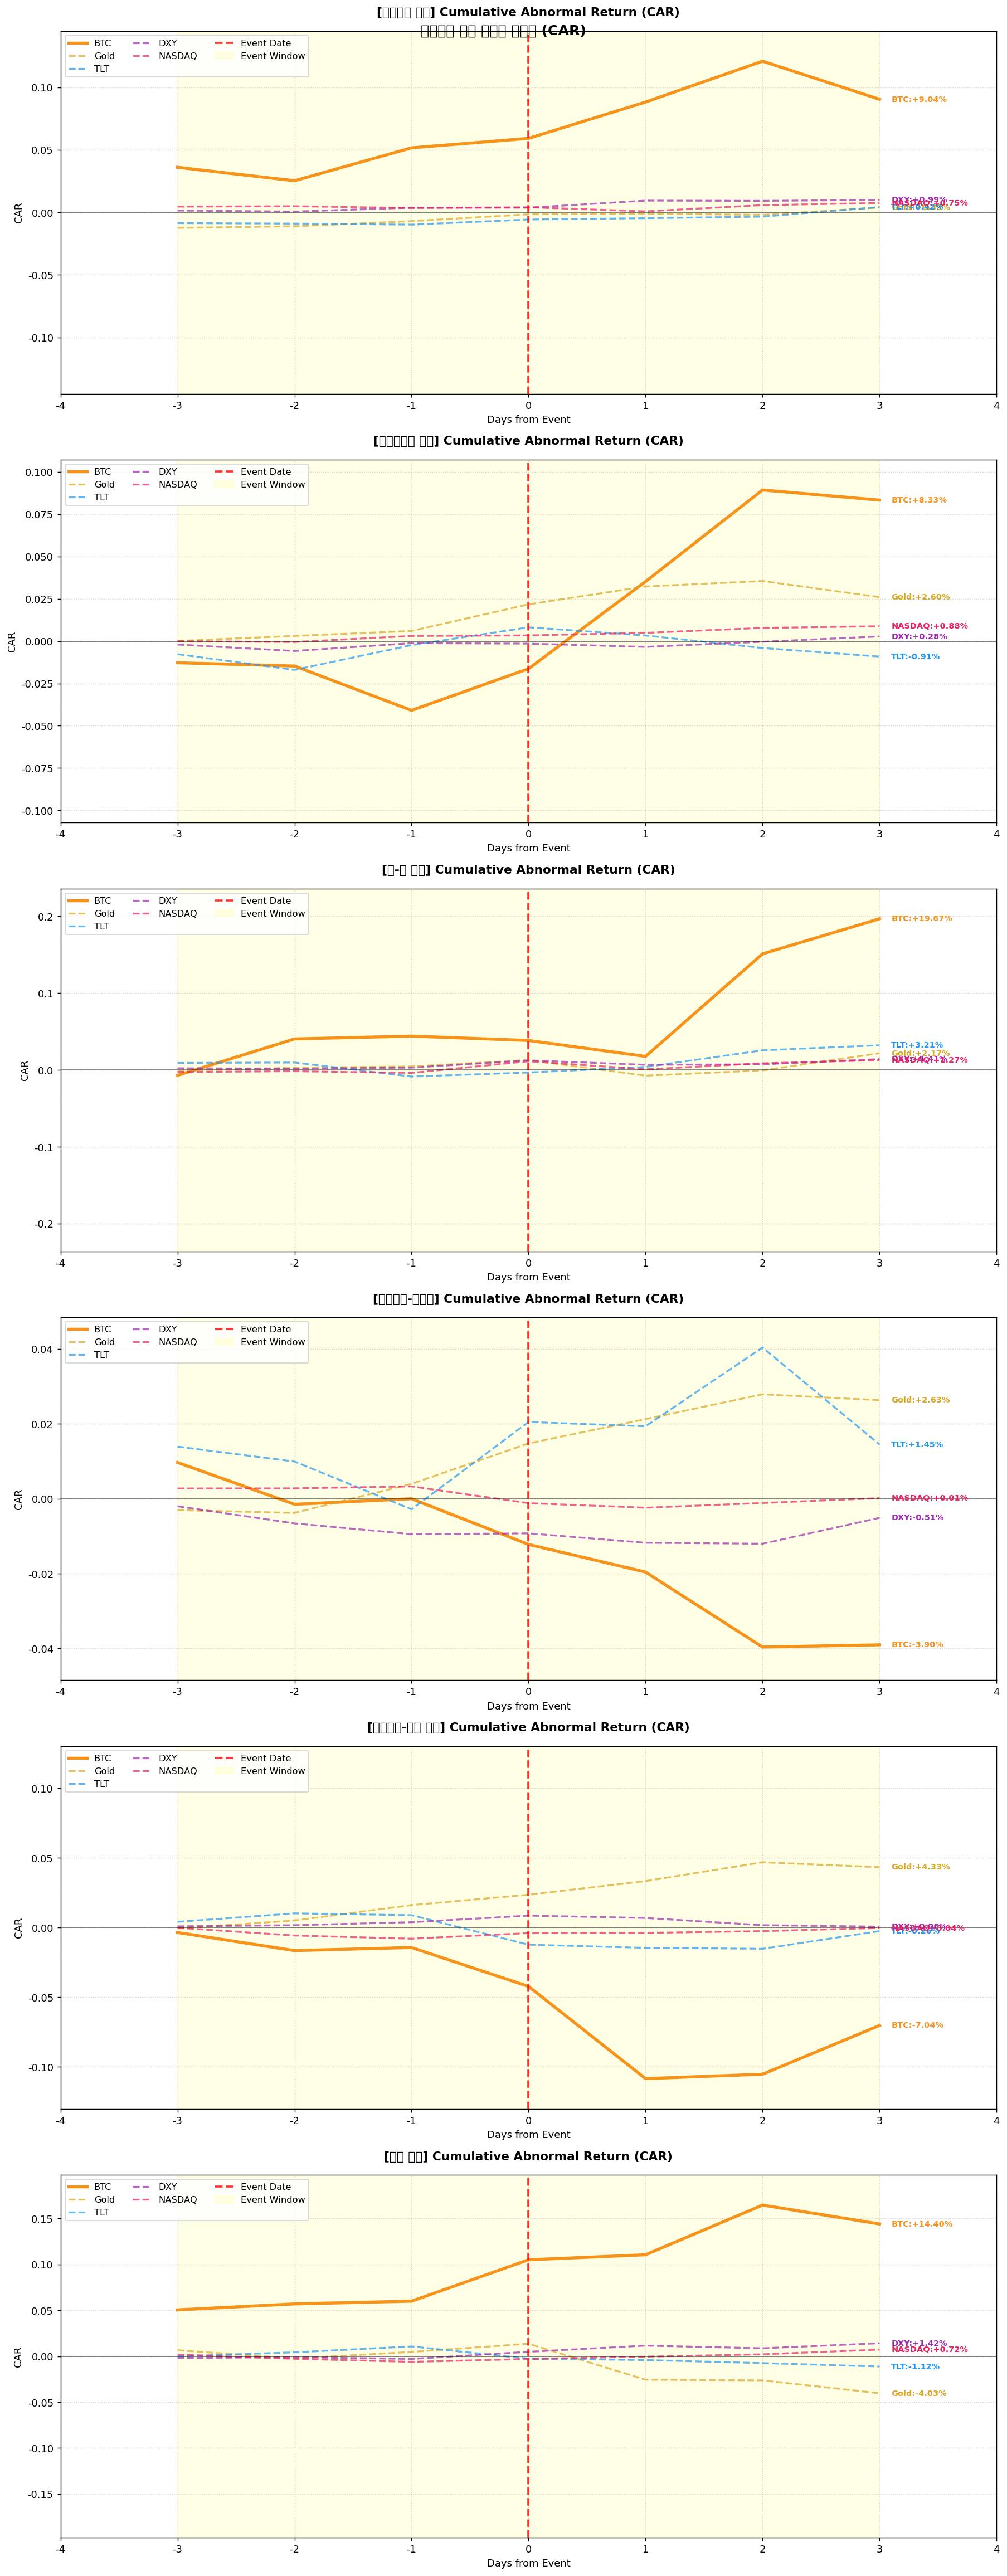

✅ event_study_CAR_timeseries.png 저장


In [49]:
# ── 6-1. 이벤트별 CAR 시계열 (개선 버전) ────────────────────────
valid_events = [e for e in EVENT_DATES if car_results.get(e)]
n = len(valid_events)
fig, axes = plt.subplots(n, 1, figsize=(14, 6*n)) # 높이를 조금 더 확보
if n == 1: axes = [axes]

for ax, event in zip(axes, valid_events):
    car = car_results[event]
    max_val = 0 # Y축 범위를 결정하기 위한 변수
    
    for asset, df_ar in car.items():
        if len(df_ar) == 0: continue
        
        # 강조 로직 유지
        lw = 3.0 if asset == 'BTC' else 1.8
        ls = '-' if asset == 'BTC' else '--'
        alpha = 1.0 if asset == 'BTC' else 0.7
        
        line = ax.plot(df_ar['day_offset'], df_ar['CAR'],
                color=ASSET_COLORS.get(asset, 'gray'),
                lw=lw, ls=ls, alpha=alpha, label=asset)
        
        # 마지막 지점에 수치 텍스트 추가 (가독성 향상)
        last_val = df_ar['CAR'].iloc[-1]
        ax.text(df_ar['day_offset'].iloc[-1] + 0.1, last_val, f'{asset}:{last_val:+.2%}', 
                fontsize=8, verticalalignment='center', color=line[0].get_color(), fontweight='bold')
        
        max_val = max(max_val, abs(df_ar['CAR'].max()), abs(df_ar['CAR'].min()))

    # 그래프 세부 설정
    ax.axvline(0, color='red', lw=2, ls='--', alpha=0.8, label='Event Date')
    ax.axhline(0, color='black', lw=1.0, alpha=0.5)
    
    # 이벤트 창 강조 영역 (전후 3일)
    ax.axvspan(-EVENT_WINDOW, EVENT_WINDOW, color='yellow', alpha=0.1, label='Event Window')
    
    # Y축 범위를 데이터에 맞춰 대칭으로 설정 (비교 용이)
    buffer = max_val * 0.2 if max_val > 0 else 0.1
    ax.set_ylim(-max_val - buffer, max_val + buffer)
    
    ax.set_xlim(-EVENT_WINDOW - 1, EVENT_WINDOW + 1)
    ax.set_title(f'[{EVENT_LABELS.get(event,event)}] Cumulative Abnormal Return (CAR)', 
                 fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel('Days from Event')
    ax.set_ylabel('CAR')
    ax.legend(fontsize=9, loc='upper left', ncol=3)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('이벤트별 누적 비정상 수익률 (CAR)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('event_study_CAR_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ event_study_CAR_timeseries.png 저장')

In [51]:
# [복구] sig_results 데이터 강제 생성 루프
sig_results = []

for event, date in EVENT_DATES.items():
    car_data = car_results.get(event, {})
    model_ev = models_v4.get(event, {})
    est_df = estimation_data.get(event, pd.DataFrame())

    for asset in ASSETS:
        df_ar = car_data.get(asset)
        if df_ar is None or len(df_ar) == 0: continue
        
        params = model_ev.get(asset)
        if not params: continue

        # AR 및 검정 데이터 산출
        est_normal = est_df.apply(lambda r: normal_return(r.to_dict(), params), axis=1)
        est_ar = est_df[asset] - est_normal
        
        # 검정 실행
        car_val, t_bmp, p_bmp = ttest_car_bmp_robust(df_ar['AR'], est_ar)
        p_block = bootstrap_block_car(df_ar['AR'], est_ar)

        # 결과 저장
        sig_results.append({
            'event': event, 
            'asset': asset, 
            'CAR': car_val,
            't_stat': t_bmp, 
            'p_norm': p_bmp, # 막대그래프 코드에서 쓰는 이름과 맞춤
            'p_boot': p_block
        })

print(f"✅ 복구 완료: {len(sig_results)}개의 결과 데이터가 생성되었습니다.")

✅ 복구 완료: 30개의 결과 데이터가 생성되었습니다.


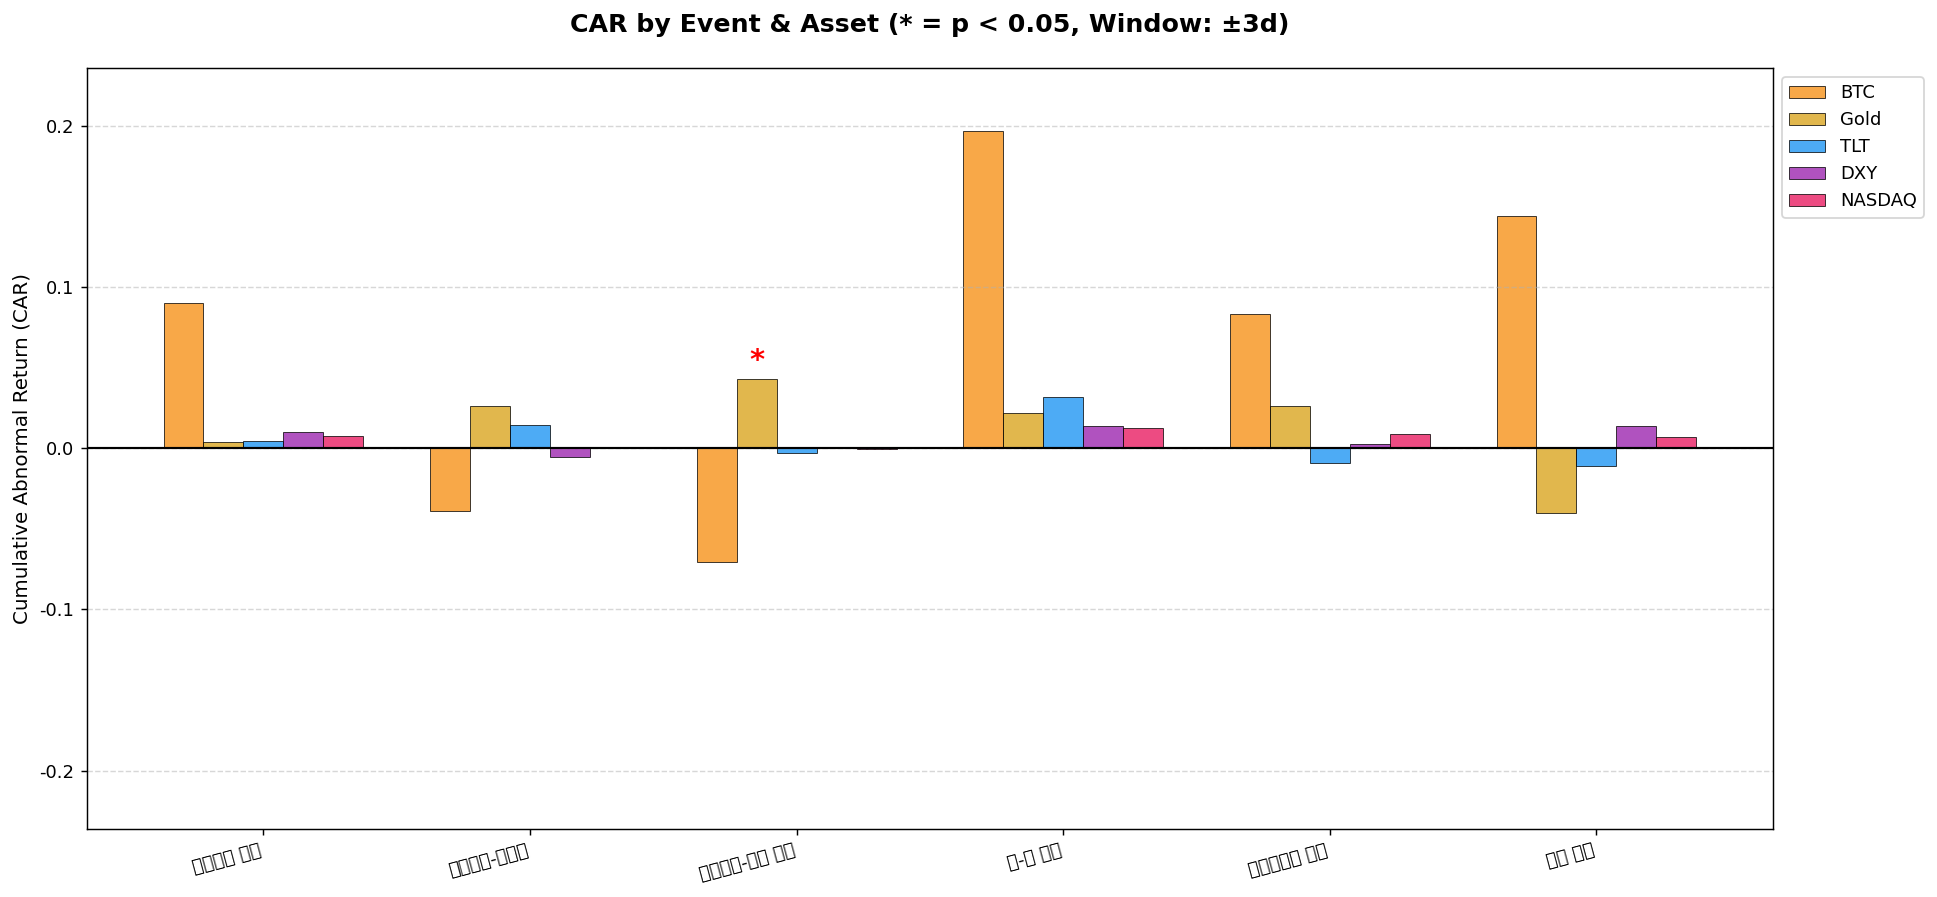

In [52]:
# ── 6-2. 자산별 × 이벤트별 CAR 막대그래프 (개선 버전) ──────────
if len(sig_results) == 0:
    print('결과 데이터(sig_results)가 없습니다.')
else:
    # 데이터프레임 변환
    sig_df = pd.DataFrame(sig_results)
    
    # 피벗 테이블 생성
    pivot = sig_df.pivot_table(
        index='event', columns='asset', values='CAR', aggfunc='first'
    ).reindex(columns=ASSETS)

    x = np.arange(len(pivot))
    width = 0.15
    fig, ax = plt.subplots(figsize=(15, 7))
    
    # 자산별 색상 매핑 (기존 ASSET_COLORS 활용 권장)
    clrs = ['#F7931A','#DAA520','#2196F3','#9C27B0','#E91E63'] 

    for i, asset in enumerate(ASSETS):
        if asset not in pivot.columns: continue
        
        vals = pivot[asset].fillna(0).values
        # 막대 그리기
        bars = ax.bar(x + i*width, vals, width, 
                      label=asset, color=clrs[i], alpha=0.8, edgecolor='black', lw=0.5)
        
        # 유의성 표시 (별표)
        for j, (bar, ev) in enumerate(zip(bars, pivot.index)):
            row = sig_df[(sig_df['event']==ev) & (sig_df['asset']==asset)]
            if len(row) > 0:
                # p_bmp 또는 p_norm 사용 (본인의 데이터프레임 컬럼명 확인)
                p_val = row['p_norm'].values[0] 
                if pd.notna(p_val) and p_val < 0.05:
                    height = bar.get_height()
                    yoff = height * 0.05 if height >= 0 else height * 0.05 - 0.01
                    ax.text(bar.get_x() + bar.get_width()/2, 
                            height + yoff, '*', 
                            ha='center', va='bottom' if height >= 0 else 'top',
                            fontsize=16, color='red', fontweight='bold')

    # 그래프 디자인
    ax.axhline(0, color='black', lw=1.2)
    ax.set_xticks(x + width * (len(ASSETS)-1)/2)
    ax.set_xticklabels([EVENT_LABELS.get(e, e) for e in pivot.index], 
                       rotation=15, ha='right', fontsize=10)
    
    ax.set_ylabel('Cumulative Abnormal Return (CAR)', fontsize=11)
    ax.set_title(f'CAR by Event & Asset (* = p < 0.05, Window: ±{EVENT_WINDOW}d)', 
                 fontsize=14, fontweight='bold', pad=20)
    
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10) # 범례를 밖으로 빼서 그래프 확보
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Y축 범위를 % 단위로 보기 좋게 설정
    vals_all = pivot.values.flatten()
    ylim = max(abs(np.nanmin(vals_all)), abs(np.nanmax(vals_all))) * 1.2
    ax.set_ylim(-ylim, ylim)

    plt.tight_layout()
    plt.savefig('event_study_CAR_bar_final.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Step 7. Baur & Lucey (2010) 최종 분류

In [53]:
if len(sig_df) == 0:
    print('결과 없음')
else:
    print('=' * 80)
    print('Baur & Lucey (2010) 최종 분류')
    print('=' * 80)

    # BTC 요약
    btc_df = sig_df[sig_df['asset'] == 'BTC'].copy()
    print(f'\n▶ BTC Safe-Haven 가설 검증:\n')
    summary = []
    for _, r in btc_df.iterrows():
        lbl = r['label'].replace('🟢 ','').replace('🔴 ','').replace('🔵 ','').replace('⚪ ','')
        summary.append({
            '이벤트'    : EVENT_LABELS.get(r['event'], r['event']),
            'CAR'       : round(r['CAR'], 4),
            'p-value(t)': round(r['p_t'], 4),
            'p-boot'    : round(r['p_boot'], 4) if pd.notna(r['p_boot']) else '-',
            '유의(5%)'  : r['sig'],
            '결론'      : r['label'],
        })
    display(pd.DataFrame(summary).set_index('이벤트'))

    # 전체 자산 피벗
    print('\n▶ 전체 자산 분류표:\n')
    pivot_lbl = sig_df.pivot_table(
        index='event', columns='asset', values='label', aggfunc='first'
    )
    pivot_lbl.index = [EVENT_LABELS.get(e,e) for e in pivot_lbl.index]
    display(pivot_lbl)

Baur & Lucey (2010) 최종 분류

▶ BTC Safe-Haven 가설 검증:



KeyError: 'label'

---
## Step 8. 결과 저장

In [ ]:
# 검정 결과
sig_df.to_csv('event_study_results.csv', index=False, encoding='utf-8-sig')

# AR 시계열 (이벤트별 × 자산별)
ar_rows = []
for event, car in car_results.items():
    for asset, df_ar in car.items():
        tmp = df_ar.copy()
        tmp['event_name'] = event
        tmp['asset']      = asset
        ar_rows.append(tmp)
if ar_rows:
    pd.concat(ar_rows, ignore_index=True).to_csv(
        'event_study_AR_timeseries.csv', index=False, encoding='utf-8-sig')

print('▶ 최종 산출물:')
for f in ['event_study_results.csv',
          'event_study_AR_timeseries.csv',
          'event_study_CAR_timeseries.png',
          'event_study_CAR_bar.png']:
    flag = '✅' if os.path.exists(f) else '📄 (실행 후 생성)'
    print(f'  {flag} {f}')

1) 현재 상태에서 수정해볼 거 gpr 추가 보조 지표로 사용하기
2) 이벤트창을 전쟁 발발 전 후를 다르게 비대칭적으로 설정해볼 것
3) 현재 추정 기간의 데이터에, 다른 작은 분쟁이나 경제적 위기가 없는건 아닌지 먼저 파악해서 중간에 팍 튀는 이상치를 제거하고, 모델을 학습시켜서 정상 수익률을 깔끔하게 계산해보는 것

-----
지금의 결과 초딩 수준 정리

비트코인의 등락폭 큰데, 그게 전쟁 때문인가?라고는 증명하기엔 어려운 자산임. 그래서 통계적으로 더 나은 정교한 분석(GARCH, 분위수 등) 필요함

----

시장 모델(Market Model)을 통해 벤치마크(NASDAQ, S&P500) 대비 각 자산의 비정상 수익률(AR)을 도출함.
자산별 변동성이 달라서 이를 보정하고자 BMP 검정과 블록 부스트트랩 적용함

- 발견: CAR으로는 비트코인이 금보다 훨씬 많이 오른 것처럼 보임. 근데 비트코인은 고유 변동성이 큰 자산이라 일반적인 상승도 통계 모델이 노이즈로 처리(비트코인(BTC)이 +20% 수익이 났는데도 Non-Sig(무의미)라고 뜨는 이유는, 비트코인에게 +20%는 사건이 아니라 일상일 수 있기 때문)함.  
-> p-value가 높게 나와서 통계적으로 우연히 일어난 일일 가능성을 배제할 수 없다는 것
  - 반면, 금은 수익률이 낮아도 변동성이 안정적이라, 작은 상승으로도 그나마 유의미한 반응임
 
- 윈도우창 17일 기준 비트코인이 유의미하게 튄 경우도 있지만, 전반적으로 안전자산 성격이 이벤트에 따라 비일관적임.

분위수 회귀랑 GARCH 통해서 변동성이 시간에 따라 어떻게 더 변하는지 확인해야함.